# MBRSET Patient-Level Evaluation (MLP with Bayesian Hyperparameter Search - UNWEIGHTED)

This notebook performs **patient-level** diabetic retinopathy classification on MBRSET using **MLP with Bayesian hyperparameter optimization**.

## Workflow
1. Load all embeddings (one CSV per embedding model)
2. Create a **single 80/20 patient-level train/test split** (reused for all embeddings)
3. Train **MLP with BayesSearchCV** for:
   - Binary DR tasks (any DR, referable)
4. Hyperparameter search includes:
   - Number of layers (1-5)
   - Neurons per layer (up to 1024)
   - Regularization (alpha), learning rate, etc.
5. Evaluate on **patient-level** (aggregate predictions per patient)
6. Generate:
   - Classification reports
   - Confusion matrices
   - ROC curves (binary tasks)
   - Training dynamics (train vs validation loss)
   
**Note**: This version **DOES NOT use sample weights** (unweighted training for comparison).

## 1. Setup and Imports

In [1]:
import os
import copy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    log_loss,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import src.retina_evaluation as reval
from src.retina_benchmark import list_embeddings_csvs
from src.retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")

print("Imports complete.")

Imports complete.


## 2. Configuration

In [2]:
# Paths and dataset
PROJECT_ROOT = Path.cwd()
DATASET_NAME = "mbrset"
VIEW = "macula"

# Split configuration
RANDOM_SEED = 42
TEST_FRAC = 0.2  # 80/20 split

# Task definitions - BINARY ONLY
BINARY_TASKS = ["task_any_dr", "task_referable"]
BINARY_TASK_MAP = {
    "task_any_dr": "task_any_diab_retino",
    "task_referable": "task_ref_macular",
}

# Model hyperparameters
CPU_COUNT = os.cpu_count() or 1

# Dimensionality Reduction
USE_PCA = True
PCA_N_COMPONENTS = 30  # Reduce huge embedding dimensions to 30 to combat overfitting

# ─── BAYESIAN HYPERPARAMETER SEARCH CONFIGURATION ───
USE_BAYESIAN_SEARCH = True
N_BAYES_ITER = 30  # Number of Bayesian optimization iterations
BAYES_CV_FOLDS = 3  # Cross-validation folds for hyperparameter search

# Define architecture options (layers 1-3, neurons 64-512) - Reduced for stability
ARCHITECTURE_OPTIONS = [
    (64,),
    (128,),
    (256,),
    (512,),
    (64, 64),
    (128, 128),
    (256, 256),
    (512, 512),
    (64, 64, 64),
    (128, 128, 128),
    (256, 256, 256),
    (512, 512, 512),
]

# Search space for MLP - use integer index to select architecture
from skopt.space import Integer, Real
SEARCH_SPACE = {
    'hidden_layer_sizes': Integer(0, len(ARCHITECTURE_OPTIONS) - 1, name='hidden_layer_sizes'),
    'alpha': Categorical([1e-6], name='alpha'),  # Fixed minimal L2 regularization (removed from search)
    'learning_rate_init': Real(1e-4, 1e-3, prior='log-uniform', name='learning_rate_init'),  # Reduced max to prevent overshooting
    'batch_size': Categorical([64], name='batch_size'),  # Fixed to 64 as requested
}

# ─── WEIGHTING CONFIGURATION ───
# Using class-balanced sample weights for training
WEIGHTING_CONFIG = {
    "binary": {
        "mode": "balanced",  # Changed from 'manual' to 'balanced' for automatic computation
        "manual": {0: 1.0, 1: 3.0},  # Kept for reference but not used
        "damping_gamma": 0.3,  # Reduced to prevent overfitting and training instability
    },
}

# Apply training weights via sample_weight in .fit()
MLP_USE_SAMPLE_WEIGHT = True

# Default threshold selection on internal validation set (binary tasks only)
THRESHOLD_METHOD = "f1"  # "youden" | "f1"
THRESHOLD_GRID_SIZE = 99

# ─── BASE MLP CONFIG (for non-search training) ───
MLP_CONFIG_BINARY = {
    "hidden_layer_sizes": (256,),  # Reduced from 512
    "alpha": 1e-6,  # Minimal regularization
    "learning_rate_init": 0.0005,  # Reduced for stability
    "batch_size": 64,
    "max_epochs": 400,
    "patience": 20,  # Increased from 10 to allow more training
    "min_delta": 1e-4,
    "warmup_epochs": 15,  # Increased from 5 to stabilize early training
}

# ─── RUNTIME FLAGS ───
RUN_WEIGHTED_VERSION = False  # UNWEIGHTED VERSION - no sample weights
RUN_UNWEIGHTED_VERSION = True  # This is the unweighted comparison notebook

# ─── PER-EMBEDDING OVERRIDES ───
# Minimal overrides if needed
EMBEDDING_OVERRIDES = {
    "dinov3_convnext_base": {},
    "dinov3_vitb16": {},
    "RETFound_mae_shanghai": {},
    "RETFound_mae_natureCFP": {},
    "RETFound_dinov2_shanghai": {},
    "vit_base": {},
    "convnextv2_base": {},
}


def resolve_config(emb_stem):
    """
    Merge base config with per-embedding overrides.
    Returns (config_dict, matched_pattern | None).
    """
    base = MLP_CONFIG_BINARY.copy()
    matched = None
    
    for pattern, overrides in EMBEDDING_OVERRIDES.items():
        if pattern in emb_stem:
            if overrides:
                base.update(overrides)
                matched = pattern
            break
    
    return base, matched


# Output configuration
RESULTS_DIR = PROJECT_ROOT / "results" / "mbrset_patient_eval_unweighted"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
SAVE_PLOTS = True

print(f"Dataset: {DATASET_NAME}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Test fraction: {TEST_FRAC}")
print(f"PCA Enabled: {USE_PCA} (components={PCA_N_COMPONENTS})")
print(f"Bayesian Search: {USE_BAYESIAN_SEARCH} (iterations={N_BAYES_ITER}, cv_folds={BAYES_CV_FOLDS})")
print(f"Search space: {len(ARCHITECTURE_OPTIONS)} architecture configurations")
print(f"Batch size: 64, Patience: 20, Warmup: 15 epochs")
print(f"Weighting (binary): UNWEIGHTED - no sample weights")
print(f"Threshold method: {THRESHOLD_METHOD} (grid={THRESHOLD_GRID_SIZE})")

Dataset: mbrset
Results directory: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval_unweighted
Random seed: 42
Test fraction: 0.2
PCA Enabled: True (components=30)
Bayesian Search: True (iterations=30, cv_folds=3)
Search space: 12 architecture configurations
Batch size: 64, Patience: 20, Warmup: 15 epochs
Weighting (binary): UNWEIGHTED - no sample weights
Threshold method: f1 (grid=99)


## 3. Load Embeddings and Create Patient-Level Split

In [3]:
# Get paths
embed_dir = PROJECT_ROOT / "data" / f"{DATASET_NAME}_embeddings"
labels_path = embed_dir / f"{DATASET_NAME}_labels" / f"labels_{DATASET_NAME}.csv"

# List all embedding files
embedding_files = list_embeddings_csvs(embed_dir)
if not embedding_files:
    raise FileNotFoundError(f"No embedding CSV files found under {embed_dir}")

print(f"Found {len(embedding_files)} embedding files:")
for i, emb in enumerate(embedding_files):
    print(f"  {i}: {emb.name}")

# Load first embedding to create the split
base_ds = load_retina_embeddings_dataset(
    dataset=DATASET_NAME,
    embeddings_csv_path=embedding_files[0],
    labels_csv_path=labels_path,
    view=VIEW,
)

# Create patient-level split (stratified by task_any_dr)
split = reval.make_patient_split(
    df=base_ds.df,
    group_col="patient_id",
    label_col="task_any_dr",
    val_frac=TEST_FRAC,
    seed=RANDOM_SEED,
)

print(f"\nPatient split:")
print(f"  Train patients: {len(split.train_patient_ids)}")
print(f"  Test patients: {len(split.val_patient_ids)}")
print(f"  Total: {len(split.train_patient_ids) + len(split.val_patient_ids)}")

# Save split for reproducibility
split_info = pd.DataFrame({
    "patient_id": list(split.train_patient_ids) + list(split.val_patient_ids),
    "split": ["train"] * len(split.train_patient_ids) + ["test"] * len(split.val_patient_ids),
})
split_info.to_csv(RESULTS_DIR / "patient_split.csv", index=False)
#print(f"\nSaved split to: {RESULTS_DIR / 'patient_split.csv'}")

Found 7 embedding files:
  0: Embeddings_convnextv2_base_mbrset.csv
  1: Embeddings_mbrset_dinov3_convnext_base.csv
  2: Embeddings_mbrset_dinov3_vitb16.csv
  3: Embeddings_mbrset_RETFound_dinov2_shanghai.csv
  4: Embeddings_mbrset_RETFound_mae_natureCFP.csv
  5: Embeddings_mbrset_RETFound_mae_shanghai.csv
  6: Embeddings_vit_base_mbrset.csv

Patient split:
  Train patients: 1032
  Test patients: 259
  Total: 1291


## 4. Helper Functions for Patient-Level Aggregation

In [4]:
from sklearn.utils.class_weight import compute_class_weight


def aggregate_patient_predictions(df, group_col="patient_id"):
    """
    Aggregate image-level predictions to patient-level by taking the majority vote
    for class labels and averaging probabilities.
    """
    patient_groups = []
    
    for patient_id, group in df.groupby(group_col):
        # Majority vote for prediction
        y_pred_patient = group["y_pred"].mode()[0] if len(group["y_pred"].mode()) > 0 else group["y_pred"].iloc[0]
        
        # Average probability
        y_proba_patient = group["y_proba"].mean()
        
        # True label (should be same for all images of a patient)
        y_true_patient = group["y_true"].mode()[0] if len(group["y_true"].mode()) > 0 else group["y_true"].iloc[0]
        
        patient_groups.append({
            "patient_id": patient_id,
            "y_true": y_true_patient,
            "y_pred": y_pred_patient,
            "y_proba": y_proba_patient,
            "n_images": len(group),
        })
    
    return pd.DataFrame(patient_groups)


def compute_balanced_weights(y, damping_gamma=0.7):
    """
    Compute balanced sample weights for training with damping to prevent extreme values.
    
    Args:
        y: Target labels
        damping_gamma: Damping factor (< 1.0 softens extremes)
    
    Returns:
        Array of sample weights normalized to mean=1.0
    """
    y = np.asarray(y)
    if y.size == 0:
        return np.asarray([], dtype=np.float32)
    
    classes = np.unique(y)
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    
    # Apply damping
    if damping_gamma is not None and float(damping_gamma) != 1.0:
        class_weights = class_weights ** float(damping_gamma)
    
    # Create mapping and get sample weights
    weight_map = {int(c): float(w) for c, w in zip(classes, class_weights)}
    sample_weights = np.array([weight_map[int(lbl)] for lbl in y], dtype=np.float32)
    
    # Normalize to mean=1.0
    mean_w = float(np.mean(sample_weights))
    if mean_w > 0:
        sample_weights = sample_weights / mean_w
    
    return sample_weights


def compute_class_weight_mapping(y, mode="balanced", manual_class_weight=None, damping_gamma=1.0):
    """
    Return a {class_label: weight} mapping.

    mode:
      - 'manual': use manual_class_weight (missing classes default to 1.0)
      - 'balanced': compute dynamic balanced weights from y
      - 'none': uniform weights

    damping_gamma < 1.0 softens extremes by applying w := w**damping_gamma.
    """
    y = np.asarray(y)
    classes = np.unique(y)
    if classes.size == 0:
        return {}

    if mode == "none":
        mapping = {int(c): 1.0 for c in classes}
    elif mode == "manual":
        manual_class_weight = manual_class_weight or {}
        mapping = {int(c): float(manual_class_weight.get(int(c), 1.0)) for c in classes}
    elif mode == "balanced":
        w = compute_class_weight(class_weight="balanced", classes=classes, y=y)
        mapping = {int(c): float(wi) for c, wi in zip(classes, w)}
    else:
        raise ValueError(f"Unknown weighting mode: {mode}")

    if damping_gamma is not None and float(damping_gamma) != 1.0:
        gamma = float(damping_gamma)
        mapping = {c: float(w ** gamma) for c, w in mapping.items()}

    return mapping


def compute_sample_weights(y, class_weight_mapping, normalize=True):
    """
    Convert a {class: weight} mapping to per-sample weights.
    If normalize=True, scale weights to mean=1.0 for stability.
    """
    y = np.asarray(y)
    if y.size == 0:
        return np.asarray([], dtype=np.float32)

    sw = np.array([class_weight_mapping.get(int(lbl), 1.0) for lbl in y], dtype=np.float32)
    if normalize and sw.size:
        mean_w = float(np.mean(sw))
        if mean_w > 0:
            sw = sw / mean_w
    return sw


def safe_fit_with_optional_sample_weight(estimator, X, y, sample_weight=None):
    """
    Fit with sample_weight if supported; otherwise fall back to unweighted fit.
    Returns True if sample_weight was used, else False.
    """
    if sample_weight is None:
        estimator.fit(X, y)
        return False
    try:
        estimator.fit(X, y, sample_weight=sample_weight)
        return True
    except TypeError:
        estimator.fit(X, y)
        return False


def find_optimal_threshold(y_true, y_proba, method="youden", grid_size=99):
    """
    Find optimal binary classification threshold using a validation set.

    method:
      - 'youden': maximise (TPR - FPR)
      - 'f1': maximise F1 score on a threshold grid
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    if y_true.size == 0:
        return 0.5

    if method == "youden":
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)
        j_scores = tpr - fpr  # Youden's J
        best_idx = int(np.argmax(j_scores))
        return float(thresholds[best_idx])

    if method == "f1":
        from sklearn.metrics import f1_score
        grid_size = int(grid_size)
        grid_size = max(11, min(grid_size, 1001))
        thresholds = np.linspace(0.01, 0.99, grid_size)
        best_t = 0.5
        best_f1 = -1.0
        for t in thresholds:
            y_pred = (y_proba >= t).astype(int)
            f1 = float(f1_score(y_true, y_pred, zero_division=0))
            if f1 > best_f1:
                best_f1 = f1
                best_t = float(t)
        return best_t

    raise ValueError(f"Unknown threshold method: {method}")


def weighted_log_loss(y_true, y_proba, labels, sample_weight=None):
    """
    Compute log loss with optional sample weights for class-aware evaluation.
    Used during early stopping so the validation metric is sensitive to
    minority-class performance without distorting training data.
    """
    return log_loss(y_true, y_proba, labels=labels, sample_weight=sample_weight)


# ─── WRAPPER CLASS FOR BAYESIAN SEARCH ───
from sklearn.base import BaseEstimator, ClassifierMixin

class MLPWrapperForBayesSearch(BaseEstimator, ClassifierMixin):
    """
    Wrapper for MLPClassifier that converts integer architecture indices to tuples.
    This allows BayesSearchCV to use Integer parameters while MLPClassifier expects tuples.
    """
    def __init__(self, hidden_layer_sizes=0, alpha=0.01, learning_rate_init=0.001, 
                 batch_size=64, max_iter=400, early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=10, random_state=42, warm_start=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.warm_start = warm_start
        self._mlp = None
    
    def _get_architecture(self):
        """Convert integer index to architecture tuple"""
        if isinstance(self.hidden_layer_sizes, int):
            return ARCHITECTURE_OPTIONS[self.hidden_layer_sizes]
        return self.hidden_layer_sizes
    
    def fit(self, X, y, sample_weight=None):
        """Fit the wrapped MLP with converted architecture"""
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch,
            alpha=self.alpha,
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size,
            max_iter=self.max_iter,
            early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state,
            warm_start=self.warm_start,
        )
        if sample_weight is not None:
            self._mlp.fit(X, y, sample_weight=sample_weight)
        else:
            self._mlp.fit(X, y)
        # Copy attributes needed for sklearn compatibility
        self.classes_ = self._mlp.classes_
        self.n_iter_ = self._mlp.n_iter_
        self.loss_ = self._mlp.loss_
        self.best_loss_ = self._mlp.best_loss_ if hasattr(self._mlp, 'best_loss_') else None
        return self
    
    def predict(self, X):
        """Predict using the wrapped MLP"""
        return self._mlp.predict(X)
    
    def predict_proba(self, X):
        """Predict probabilities using the wrapped MLP"""
        return self._mlp.predict_proba(X)
    
    def score(self, X, y, sample_weight=None):
        """Return the mean accuracy"""
        return self._mlp.score(X, y, sample_weight=sample_weight)


# ─── WRAPPER CLASS FOR BAYESIAN SEARCH ───
from sklearn.base import BaseEstimator, ClassifierMixin

class MLPWrapperForBayesSearch(BaseEstimator, ClassifierMixin):
    """
    Wrapper for MLPClassifier that converts integer architecture indices to tuples.
    This allows BayesSearchCV to use Integer parameters while MLPClassifier expects tuples.
    """
    def __init__(self, hidden_layer_sizes=0, alpha=0.01, learning_rate_init=0.001, 
                 batch_size=64, max_iter=400, early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=10, random_state=42, warm_start=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.warm_start = warm_start
        self._mlp = None
    
    def _get_architecture(self):
        """Convert integer index to architecture tuple"""
        if isinstance(self.hidden_layer_sizes, int):
            return ARCHITECTURE_OPTIONS[self.hidden_layer_sizes]
        return self.hidden_layer_sizes
    
    def fit(self, X, y, sample_weight=None):
        """Fit the wrapped MLP with converted architecture"""
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch,
            alpha=self.alpha,
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size,
            max_iter=self.max_iter,
            early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state,
            warm_start=self.warm_start,
        )
        if sample_weight is not None:
            self._mlp.fit(X, y, sample_weight=sample_weight)
        else:
            self._mlp.fit(X, y)
        # Copy attributes needed for sklearn compatibility
        self.classes_ = self._mlp.classes_
        self.n_iter_ = self._mlp.n_iter_
        self.loss_ = self._mlp.loss_
        self.best_loss_ = self._mlp.best_loss_ if hasattr(self._mlp, 'best_loss_') else None
        return self
    
    def predict(self, X):
        """Predict using the wrapped MLP"""
        return self._mlp.predict(X)
    
    def predict_proba(self, X):
        """Predict probabilities using the wrapped MLP"""
        return self._mlp.predict_proba(X)
    
    def score(self, X, y, sample_weight=None):
        """Return the mean accuracy"""
        return self._mlp.score(X, y, sample_weight=sample_weight)


def plot_confusion_matrix(cm, title, save_path=None, show=True):
    """Plot confusion matrix."""
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    im = ax.imshow(cm, cmap="viridis", interpolation="nearest")
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis="both", labelsize=9)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)
    cbar.set_label("Count", fontsize=9)

    thresh = cm.max() / 2.0 if cm.size else 0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(
            j, i, f"{val}",
            ha="center", va="center",
            color="white" if val > thresh else "black",
            fontsize=10, fontweight="bold",
        )
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_roc_curve(fpr, tpr, auc, title, save_path=None, show=True):
    """Plot ROC curve."""
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = Normalize(vmin=0.0, vmax=1.0)
    lc = LineCollection(segments, cmap="plasma", norm=norm)
    lc.set_array(fpr)
    lc.set_linewidth(2.6)
    ax.add_collection(lc)
    
    ax.plot([0, 1], [0, 1], linestyle="--", color="#666", linewidth=1.2, label="Chance")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{title}\nAUC = {auc:.3f}", fontsize=11, pad=12)
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.tick_params(axis="both", labelsize=9)
    ax.legend(loc="lower right", fontsize=9)
    cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("FPR", fontsize=9)
    cbar.ax.tick_params(labelsize=9)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


print("Helper functions defined.")

Helper functions defined.


## 5. Train and Evaluate MLP with Bayesian Hyperparameter Search

For each embedding file and binary task, train MLP with BayesSearchCV, then evaluate at patient-level.


Embedding 1/7: Embeddings_convnextv2_base_mbrset



--- Task: task_any_diab_retino (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidat

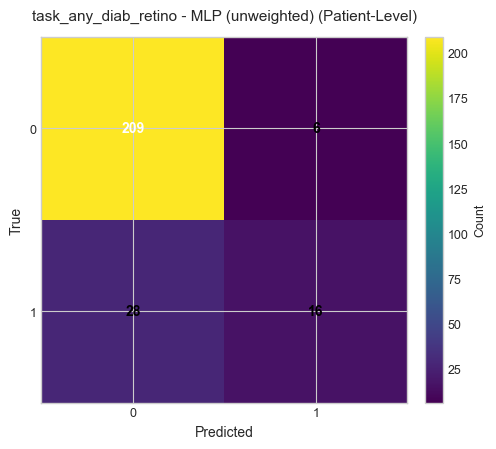

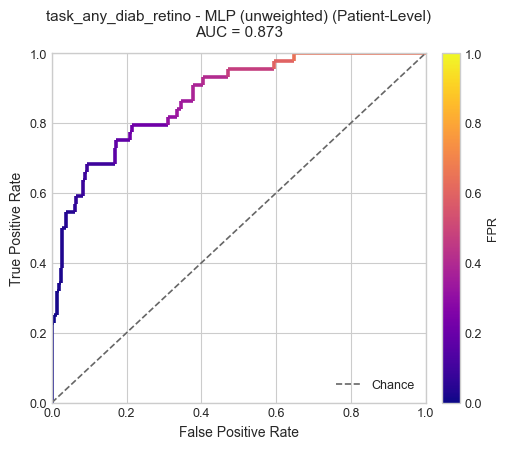


--- Task: task_ref_macular (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, 

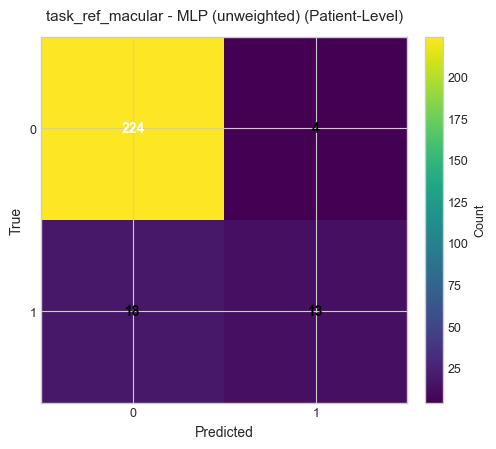

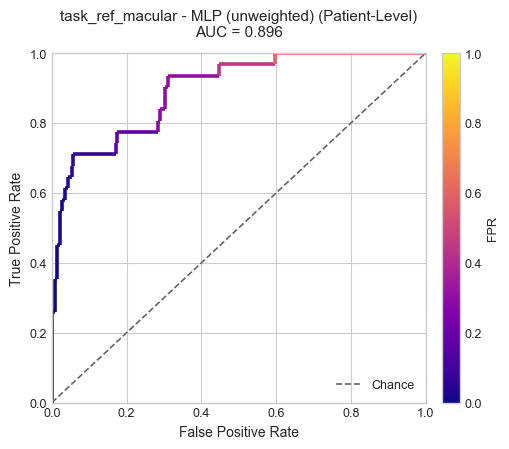


Embedding 2/7: Embeddings_mbrset_dinov3_convnext_base

--- Task: task_any_diab_retino (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, 

c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.float64(1e-06), np.int64(64), np.int64(11), 0.0001] before, using random point [1e-06, 64, np.int64(6), 0.00039063800116053]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.float64(1e-06), np.int64(64), np.int64(11), 0.0001] before, using random point [1e-06, 64, np.int64(10), 0.0005585298731954537]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
  Best CV F1 Score: 0.4448
  Best parameters:
    hidden_layer_sizes: (512, 512, 512)
    alpha: 1e-06
    batch_size: 64
    learning_rate_init: 0.00010028714628793599
  Optimal threshold (f1): 0.360

  Patient-Level Metrics:
  Accuracy: 0.853
  Balanced Accuracy: 0.613
  F1 Score: 0.367
  Precision: 0.688
  Recall (Sensitivity): 0.250
  ROC AUC: 0.821

  Classification Report (Patient-Level):
            

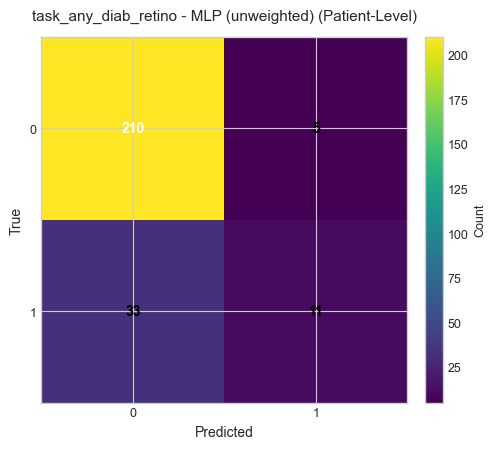

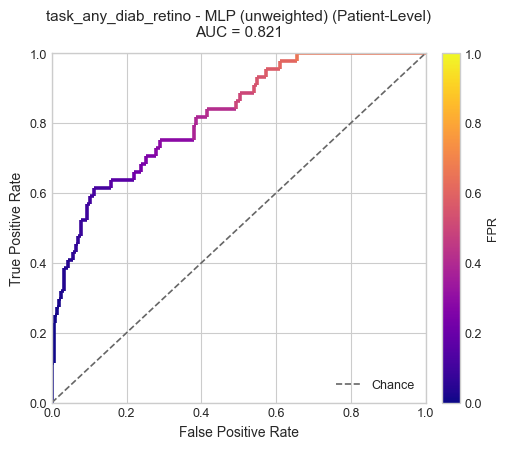


--- Task: task_ref_macular (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, 

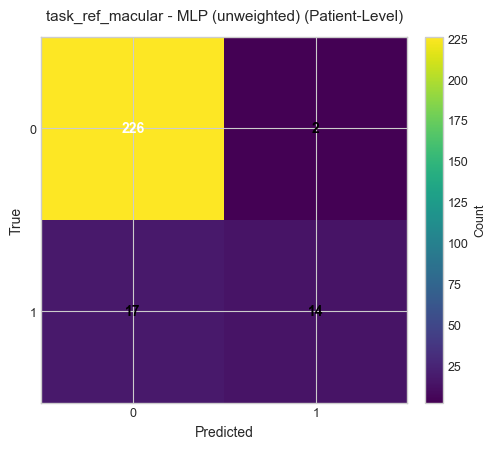

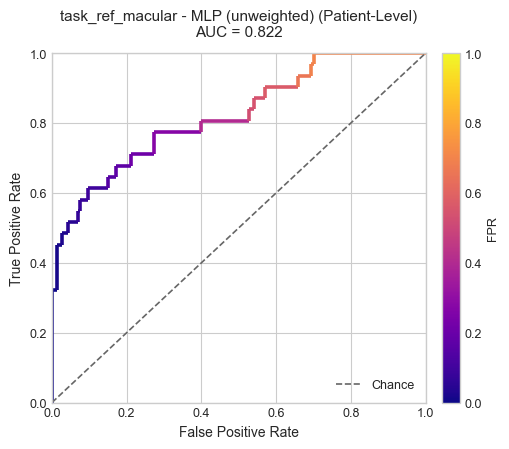


Embedding 3/7: Embeddings_mbrset_dinov3_vitb16

--- Task: task_any_diab_retino (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalli

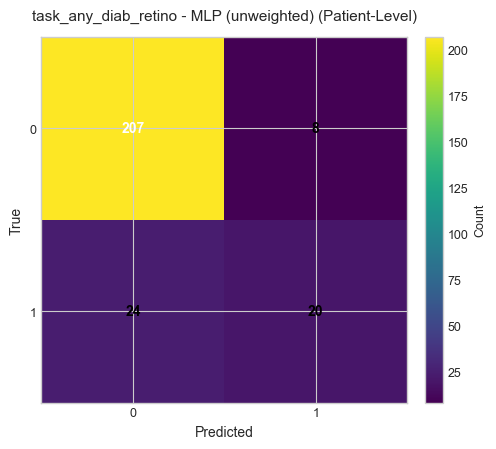

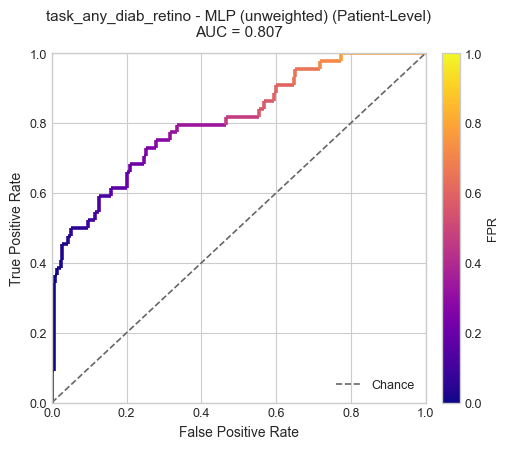


--- Task: task_ref_macular (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, 

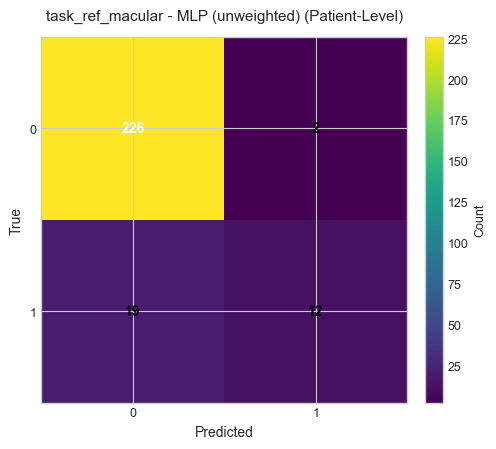

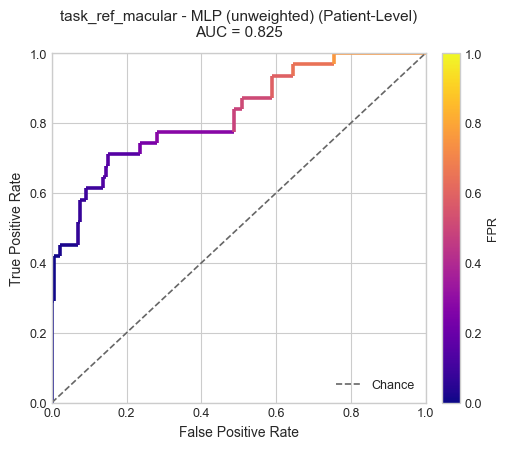


Embedding 4/7: Embeddings_mbrset_RETFound_dinov2_shanghai

--- Task: task_any_diab_retino (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidat

c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.float64(1e-06), np.int64(64), np.int64(9), 0.001] before, using random point [1e-06, 64, np.int64(3), 0.00041878556726810133]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
  Best CV F1 Score: 0.4814
  Best parameters:
    hidden_layer_sizes: (128, 128, 128)
    alpha: 1e-06
    batch_size: 64
    learning_rate_init: 0.001
  Optimal threshold (f1): 0.320

  Patient-Level Metrics:
  Accuracy: 0.876
  Balanced Accuracy: 0.691
  F1 Score: 0.529
  Precision: 0.750
  Recall (Sensitivity): 0.409
  ROC AUC: 0.798

  Classification Report (Patient-Level):
              precision    recall  f1-score   support

           0      0.889     0.972     0.929       215
           1      0.750     0.409     0.529        44

    accuracy                          0.876       259
   macro avg      0.820     0.691     0.729       259
weighted avg      0.866     0.876     0.861       259



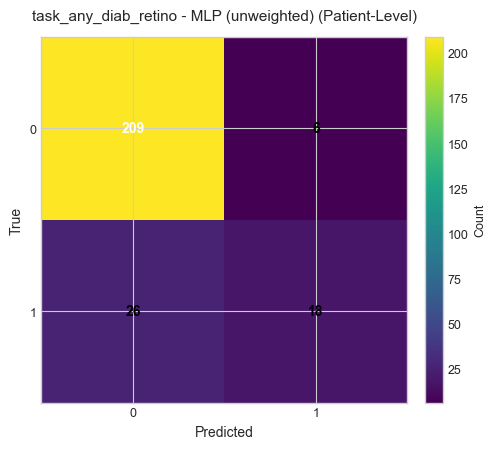

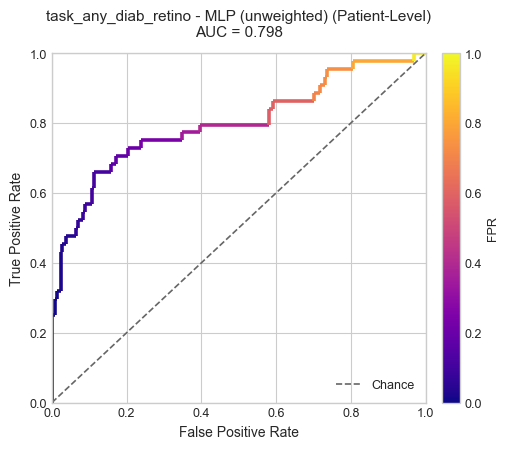


--- Task: task_ref_macular (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, 

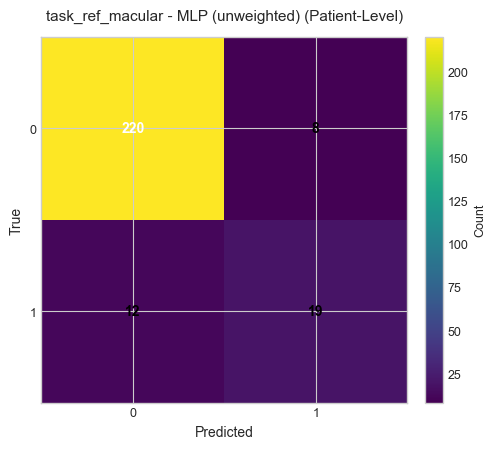

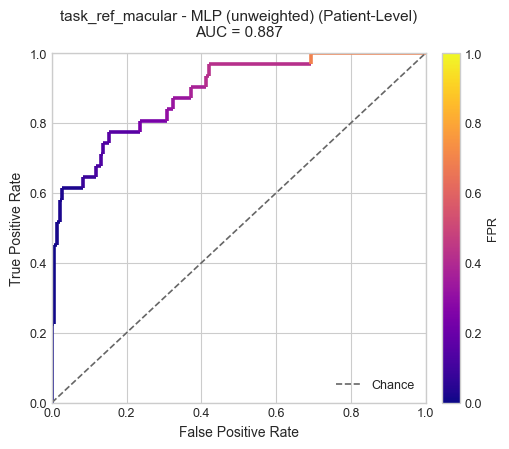


Embedding 5/7: Embeddings_mbrset_RETFound_mae_natureCFP

--- Task: task_any_diab_retino (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates

c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.float64(1e-06), np.int64(64), np.int64(6), 0.001] before, using random point [1e-06, 64, np.int64(4), 0.0005787750659981944]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.float64(1e-06), np.int64(64), np.int64(6), 0.001] before, using random point [1e-06, 64, np.int64(4), 0.00020956165367341394]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


...

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.float64(1e-06), np.int64(64), np.int64(6), 0.001] before, using random point [1e-06, 64, np.int64(3), 0.0002659934952503225]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.float64(1e-06), np.int64(64), np.int64(6), 0.001] before, using random point [1e-06, 64, np.int64(3), 0.00041878556726810133]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
  Best CV F1 Score: 0.2862
  Best parameters:
    hidden_layer_sizes: (256, 256)
    alpha: 1e-06
    batch_size: 64
    learning_rate_init: 0.001
  Optimal threshold (f1): 0.370

  Patient-Level Metrics:
  Accuracy: 0.842
  Balanced Accuracy: 0.652
  F1 Score: 0.438
  Precision: 0.552
  Recall (Sensitivity): 0.364
  ROC AUC: 0.806

  Classification Report (Patient-Level):
              precision    recall  f1-score   support

           0      0.878     0.940     0.908       215
           1      0.552     0.364     0.438        44

    accuracy                          0.842       259
   macro avg      0.715     0.652     0.673       259
weighted avg      0.823     0.842     0.828       259



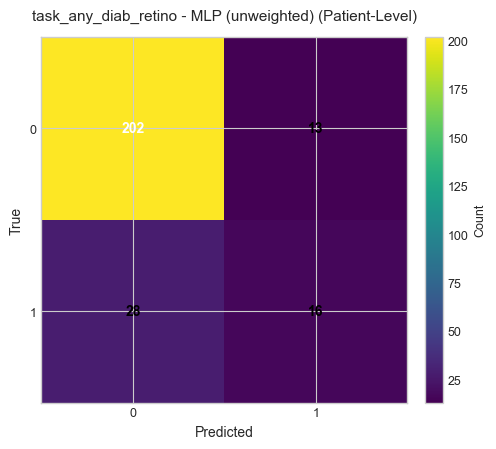

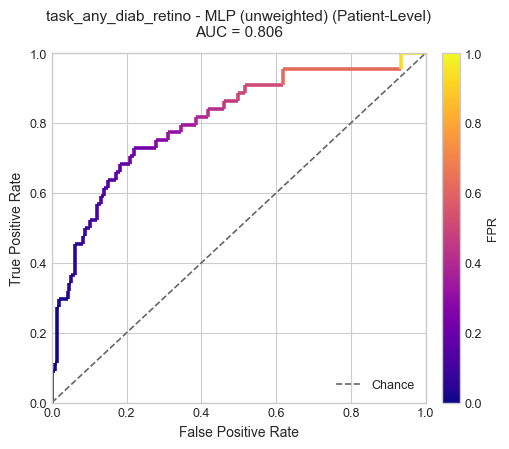


--- Task: task_ref_macular (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, 

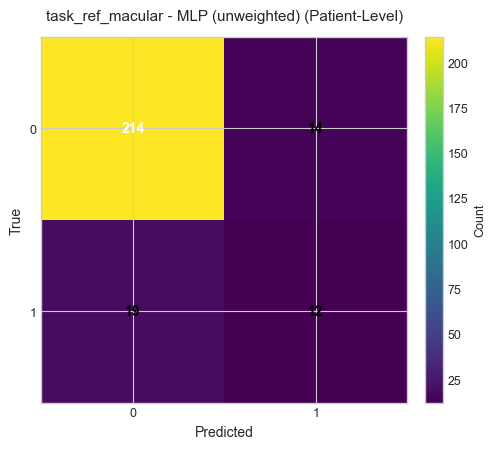

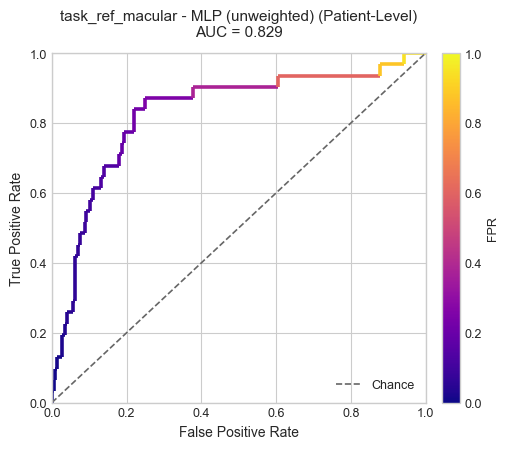


Embedding 6/7: Embeddings_mbrset_RETFound_mae_shanghai

--- Task: task_any_diab_retino (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates,

c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.float64(1e-06), np.int64(64), np.int64(3), 0.001] before, using random point [1e-06, 64, np.int64(0), 0.0007622486900414002]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
  Best CV F1 Score: 0.2593
  Best parameters:
    hidden_layer_sizes: (512,)
    alpha: 1e-06
    batch_size: 64
    learning_rate_init: 0.0007931505321491212
  Optimal threshold (f1): 0.250

  Patient-Level Metrics:
  Accuracy: 0.776
  Balanced Accuracy: 0.621
  F1 Score: 0.370
  Precision: 0.354
  Recall (Sensitivity): 0.386
  ROC AUC: 0.681

  Classification Report (Patient-Level):
              precision    recall  f1-score   support

           0      0.872   

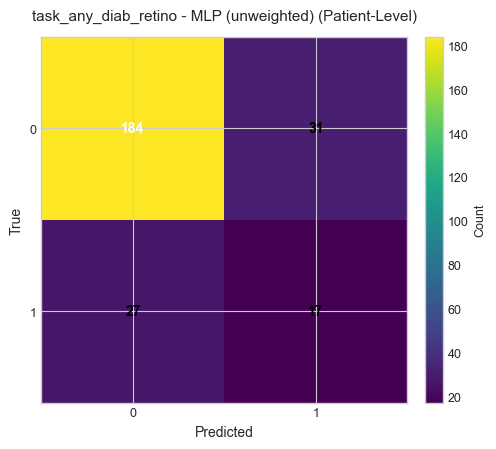

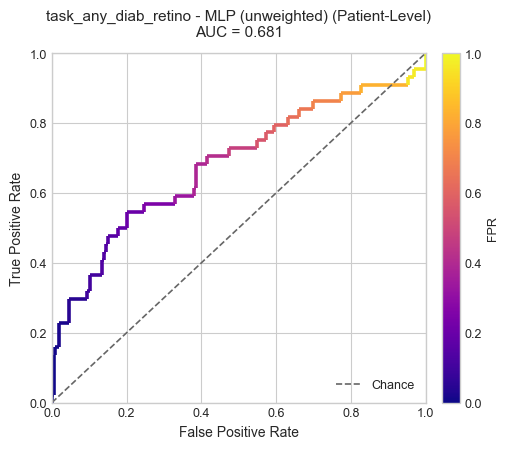


--- Task: task_ref_macular (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, 

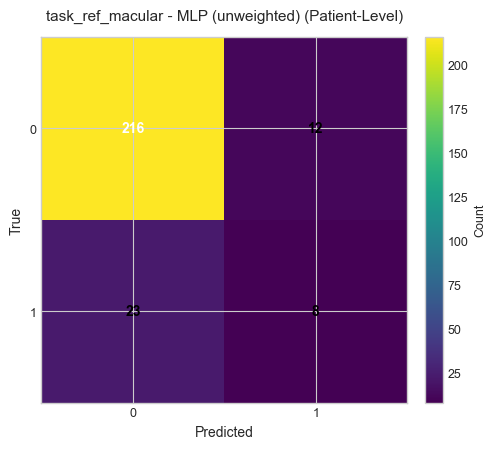

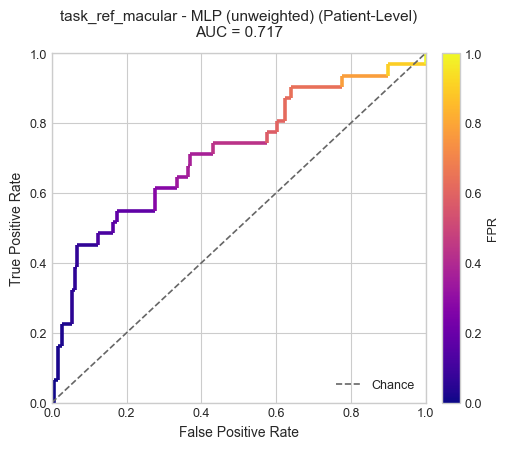


Embedding 7/7: Embeddings_vit_base_mbrset

--- Task: task_any_diab_retino (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 

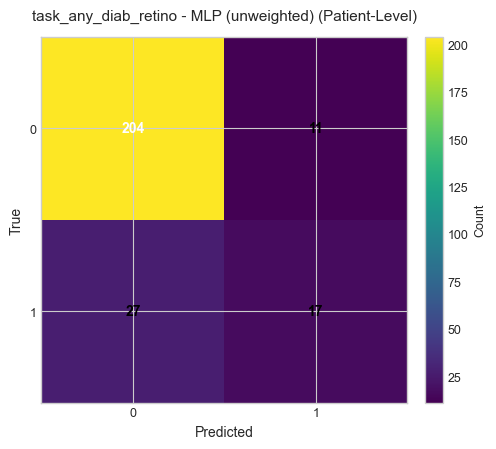

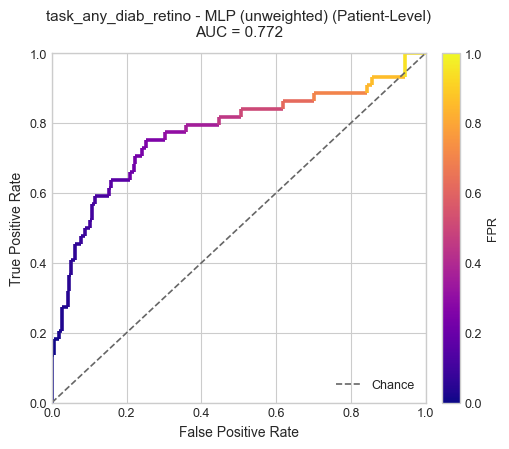


--- Task: task_ref_macular (binary) ---
  Train: 2064 images, 1032 patients
  Test: 518 images, 259 patients
  Class distribution (train): {np.int64(0): np.int64(1697), np.int64(1): np.int64(367)}
  Applying PCA (n_components=30)...
  New feature shape: (2064, 30)
  Training without sample weights

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures
  Bayesian iterations: 30, CV folds: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, 

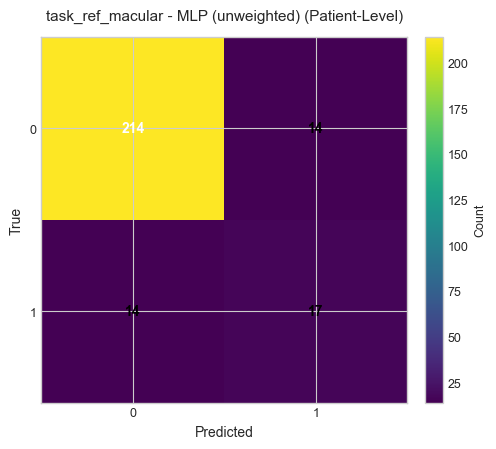

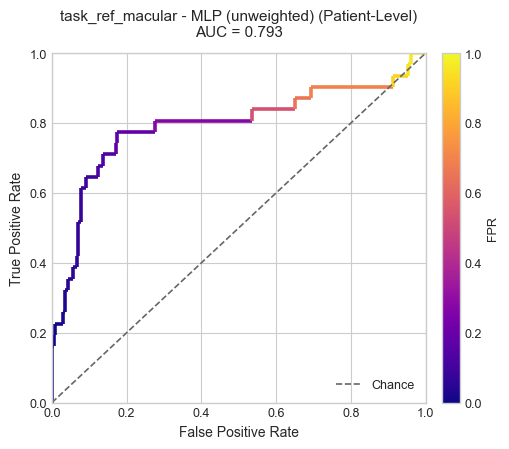


Training and evaluation complete!


In [5]:
# Storage for results
all_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    print(f"\n{'='*80}")
    print(f"Embedding {emb_idx+1}/{len(embedding_files)}: {emb_path.stem}")
    print(f"{'='*80}")
    
    # Load dataset
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )
    
    # Apply split
    train_df, test_df = reval.apply_patient_split(ds.df, split, group_col="patient_id")
    
    # Loop over BINARY tasks only
    for task in BINARY_TASKS:
        if task not in ds.df.columns:
            continue
        
        display_task = BINARY_TASK_MAP.get(task, task)
        
        print(f"\n--- Task: {display_task} (binary) ---")
        
        # Prepare data
        train_work = train_df.dropna(subset=[task]).copy()
        test_work = test_df.dropna(subset=[task]).copy()
        
        if train_work.empty or test_work.empty:
            print(f"  Skipping {task}: insufficient data")
            continue
        
        X_train = train_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_train = train_work[task].astype(int).to_numpy()
        X_test = test_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_test = test_work[task].astype(int).to_numpy()
        
        # Print class distribution
        classes, counts = np.unique(y_train, return_counts=True)
        print(f"  Train: {len(X_train)} images, {train_work['patient_id'].nunique()} patients")
        print(f"  Test: {len(X_test)} images, {test_work['patient_id'].nunique()} patients")
        print(f"  Class distribution (train): {dict(zip(classes.astype(int), counts))}")

        # Apply PCA if enabled
        if USE_PCA:
            print(f"  Applying PCA (n_components={PCA_N_COMPONENTS})...")
            pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            print(f"  New feature shape: {X_train.shape}")

        # Resolve per-embedding configs (overrides applied if available)
        mlp_cfg, mlp_match = resolve_config(emb_path.stem)
        if mlp_match:
            print(f"  Per-embedding overrides applied (matched: {mlp_match})")

        # Prepare training with proper scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Compute sample weights for training
        if RUN_WEIGHTED_VERSION:
            sample_weights = compute_balanced_weights(y_train)
            weight_name = "weighted"
            print(f"  Using balanced sample weights (mean={sample_weights.mean():.3f})")
        else:
            sample_weights = None
            weight_name = "unweighted"
            print(f"  Training without sample weights")
        
        # Split training data for validation (for threshold optimization)
        from sklearn.model_selection import train_test_split
        X_train_inner, X_val_inner, y_train_inner, y_val_inner = train_test_split(
            X_train_scaled, y_train, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train
        )
        
        print(f"\n  Training MLP with Bayesian Hyperparameter Search...")
        print(f"  Search space: {len(ARCHITECTURE_OPTIONS)} architectures")
        print(f"  Bayesian iterations: {N_BAYES_ITER}, CV folds: {BAYES_CV_FOLDS}")
        
        if USE_BAYESIAN_SEARCH:
            # Create base MLP wrapper estimator
            base_mlp = MLPWrapperForBayesSearch(
                max_iter=mlp_cfg["max_epochs"],
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=mlp_cfg["patience"],
                random_state=RANDOM_SEED,
                warm_start=False,
            )
            
            # Create BayesSearchCV optimizer
            bayes_search = BayesSearchCV(
                estimator=base_mlp,
                search_spaces=SEARCH_SPACE,
                n_iter=N_BAYES_ITER,
                cv=BAYES_CV_FOLDS,
                n_jobs=1,  # MLP is already multithreaded
                scoring='f1',  # Changed from 'roc_auc' to 'f1' for better classification performance
                random_state=RANDOM_SEED,
                verbose=1,
            )
            
            # Fit with sample weights if available
            if sample_weights is not None:
                bayes_search.fit(X_train_scaled, y_train, sample_weight=sample_weights)
            else:
                bayes_search.fit(X_train_scaled, y_train)
            
            # Get best model
            best_model = bayes_search.best_estimator_
            best_params = bayes_search.best_params_
            best_score = bayes_search.best_score_
            
            # Convert architecture index to tuple for display
            if 'hidden_layer_sizes' in best_params and isinstance(best_params['hidden_layer_sizes'], int):
                arch_display = ARCHITECTURE_OPTIONS[best_params['hidden_layer_sizes']]
            else:
                arch_display = best_params.get('hidden_layer_sizes', 'unknown')
            
            print(f"  Best CV F1 Score: {best_score:.4f}")
            print(f"  Best parameters:")
            print(f"    hidden_layer_sizes: {arch_display}")
            for key, value in best_params.items():
                if key != 'hidden_layer_sizes':
                    print(f"    {key}: {value}")
        
        else:
            # Train with default config (no hyperparameter search)
            print(f"  Training with default config (no Bayesian search)")
            print(f"  Config: hidden={mlp_cfg['hidden_layer_sizes']}, alpha={mlp_cfg['alpha']}, lr={mlp_cfg['learning_rate_init']}")
            
            best_model = MLPClassifier(
                hidden_layer_sizes=mlp_cfg["hidden_layer_sizes"],
                alpha=mlp_cfg["alpha"],
                learning_rate_init=mlp_cfg["learning_rate_init"],
                batch_size=mlp_cfg["batch_size"],
                max_iter=mlp_cfg["max_epochs"],
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=mlp_cfg["patience"],
                random_state=RANDOM_SEED,
            )
            
            if sample_weights is not None:
                best_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
            else:
                best_model.fit(X_train_scaled, y_train)
        
        # Find optimal threshold on validation set
        val_proba = best_model.predict_proba(X_val_inner)[:, 1]
        opt_thresh = find_optimal_threshold(y_val_inner, val_proba, method=THRESHOLD_METHOD)
        print(f"  Optimal threshold ({THRESHOLD_METHOD}): {opt_thresh:.3f}")
        
        # Get predictions on test set
        y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
        y_pred_test = (y_proba_test >= opt_thresh).astype(int)
        
        # Create image-level results DataFrame
        test_results = test_work[["patient_id"]].copy()
        test_results["y_true"] = y_test
        test_results["y_pred"] = y_pred_test
        test_results["y_proba"] = y_proba_test
        
        # Aggregate to patient level
        patient_results = aggregate_patient_predictions(test_results, group_col="patient_id")
        
        y_true_patient = patient_results["y_true"].to_numpy()
        y_pred_patient = patient_results["y_pred"].to_numpy()
        y_proba_patient = patient_results["y_proba"].to_numpy()
        
        # Calculate comprehensive metrics
        from sklearn.metrics import f1_score, precision_score, recall_score, balanced_accuracy_score
        
        accuracy = (y_true_patient == y_pred_patient).mean()
        f1 = f1_score(y_true_patient, y_pred_patient, zero_division=0)
        precision = precision_score(y_true_patient, y_pred_patient, zero_division=0)
        recall = recall_score(y_true_patient, y_pred_patient, zero_division=0)
        balanced_acc = balanced_accuracy_score(y_true_patient, y_pred_patient)
        fpr, tpr, _ = roc_curve(y_true_patient, y_proba_patient)
        auc = roc_auc_score(y_true_patient, y_proba_patient)
        
        print(f"\n  Patient-Level Metrics:")
        print(f"  Accuracy: {accuracy:.3f}")
        print(f"  Balanced Accuracy: {balanced_acc:.3f}")
        print(f"  F1 Score: {f1:.3f}")
        print(f"  Precision: {precision:.3f}")
        print(f"  Recall (Sensitivity): {recall:.3f}")
        print(f"  ROC AUC: {auc:.3f}")
        
        # Generate classification report
        report_text = classification_report(y_true_patient, y_pred_patient, digits=3)
        print(f"\n  Classification Report (Patient-Level):")
        print(report_text)
        
        # Confusion matrix
        cm = confusion_matrix(y_true_patient, y_pred_patient)
        
        # Save outputs
        out_dir = RESULTS_DIR / f"{emb_idx:02d}_{emb_path.stem}" / display_task / "mlp"
        out_dir.mkdir(parents=True, exist_ok=True)
        
        # Save report
        (out_dir / "classification_report.txt").write_text(report_text, encoding="utf-8")
        
        # Save best hyperparameters if using Bayesian search
        if USE_BAYESIAN_SEARCH:
            import json
            with open(out_dir / "best_hyperparameters.json", "w") as f:
                json.dump({k: str(v) for k, v in best_params.items()}, f, indent=2)
        
        # Save confusion matrix
        pd.DataFrame(cm).to_csv(out_dir / "confusion_matrix.csv", index=False)
        plot_confusion_matrix(
            cm,
            title=f"{display_task} - MLP ({weight_name}) (Patient-Level)",
            save_path=out_dir / "confusion_matrix.png" if SAVE_PLOTS else None,
            show=SHOW_PLOTS,
        )
        
        # Save ROC curve
        pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(out_dir / "roc_curve.csv", index=False)
        plot_roc_curve(
            fpr, tpr, auc,
            title=f"{display_task} - MLP ({weight_name}) (Patient-Level)",
            save_path=out_dir / "roc_curve.png" if SAVE_PLOTS else None,
            show=SHOW_PLOTS,
        )
        
        # Save patient-level predictions
        patient_results.to_csv(out_dir / "patient_predictions.csv", index=False)
        
        # Store summary with comprehensive metrics
        all_results.append({
            "embedding_idx": emb_idx,
            "embedding": emb_path.stem,
            "task": display_task,
            "model": "mlp",
            "weighting": weight_name,
            "n_patients": len(patient_results),
            "accuracy": float(accuracy),
            "balanced_accuracy": float(balanced_acc),
            "f1_score": float(f1),
            "precision": float(precision),
            "recall": float(recall),
            "auc": float(auc),
            "best_cv_score": float(best_score) if USE_BAYESIAN_SEARCH else None,
            "output_dir": str(out_dir),
        })

print(f"\n{'='*80}")
print("Training and evaluation complete!")
print(f"{'='*80}")

## 6. Summary Table

In [6]:
# Create summary DataFrame
summary_df = pd.DataFrame(all_results)

# Save summary
summary_df.to_csv(RESULTS_DIR / "summary.csv", index=False)
print(f"Saved summary to: {RESULTS_DIR / 'summary.csv'}")

# Display summary with comprehensive metrics
print("\nSummary of Results (Patient-Level):")
display_cols = ["embedding", "task", "model", "weighting", "n_patients", "accuracy", "balanced_accuracy", "f1_score", "auc"]
if USE_BAYESIAN_SEARCH and "best_cv_score" in summary_df.columns:
    display_cols.insert(5, "best_cv_score")
print(summary_df[display_cols].to_string(index=False))

summary_df

Saved summary to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval_unweighted\summary.csv

Summary of Results (Patient-Level):
                                 embedding                 task model  weighting  n_patients  best_cv_score  accuracy  balanced_accuracy  f1_score      auc
         Embeddings_convnextv2_base_mbrset task_any_diab_retino   mlp unweighted         259       0.525098  0.868726           0.667865  0.484848 0.872939
         Embeddings_convnextv2_base_mbrset     task_ref_macular   mlp unweighted         259       0.549223  0.915058           0.700905  0.541667 0.895869
    Embeddings_mbrset_dinov3_convnext_base task_any_diab_retino   mlp unweighted         259       0.444820  0.853282           0.613372  0.366667 0.820613
    Embeddings_mbrset_dinov3_convnext_base     task_ref_macular   mlp unweighted         259       0.461531  0.926641           0.721420  0.595745 0.821732
           Embeddin

,embedding_idx,embedding,task,model,weighting,n_patients,accuracy,balanced_accuracy,f1_score,precision,recall,auc,best_cv_score,output_dir
0,0,Embeddings_convnextv2_base_mbrset,task_any_diab_retino,mlp,unweighted,259,0.868726,0.667865,0.484848,0.727273,0.363636,0.872939,0.525098,c:\Users\Julian\OneDrive\Desktop\testing-retin...
1,0,Embeddings_convnextv2_base_mbrset,task_ref_macular,mlp,unweighted,259,0.915058,0.700905,0.541667,0.764706,0.419355,0.895869,0.549223,c:\Users\Julian\OneDrive\Desktop\testing-retin...
2,1,Embeddings_mbrset_dinov3_convnext_base,task_any_diab_retino,mlp,unweighted,259,0.853282,0.613372,0.366667,0.687500,0.250000,0.820613,0.444820,c:\Users\Julian\OneDrive\Desktop\testing-retin...
3,1,Embeddings_mbrset_dinov3_convnext_base,task_ref_macular,mlp,unweighted,259,0.926641,0.721420,0.595745,0.875000,0.451613,0.821732,0.461531,c:\Users\Julian\OneDrive\Desktop\testing-retin...
4,2,Embeddings_mbrset_dinov3_vitb16,task_any_diab_retino,mlp,unweighted,259,0.876448,0.708668,0.555556,0.714286,0.454545,0.807400,0.471878,c:\Users\Julian\OneDrive\Desktop\testing-retin...
5,2,Embeddings_mbrset_dinov3_vitb16,task_ref_macular,mlp,unweighted,259,0.918919,0.689162,0.533333,0.857143,0.387097,0.824986,0.526856,c:\Users\Julian\OneDrive\Desktop\testing-retin...
6,3,Embeddings_mbrset_RETFound_dinov2_shanghai,task_any_diab_retino,mlp,unweighted,259,0.876448,0.690592,0.529412,0.750000,0.409091,0.798097,0.481361,c:\Users\Julian\OneDrive\Desktop\testing-retin...
7,3,Embeddings_mbrset_RETFound_dinov2_shanghai,task_ref_macular,mlp,unweighted,259,0.922780,0.788908,0.655172,0.703704,0.612903,0.886531,0.534534,c:\Users\Julian\OneDrive\Desktop\testing-retin...
8,4,Embeddings_mbrset_RETFound_mae_natureCFP,task_any_diab_retino,mlp,unweighted,259,0.841699,0.651586,0.438356,0.551724,0.363636,0.805814,0.286186,c:\Users\Julian\OneDrive\Desktop\testing-retin...
9,4,Embeddings_mbrset_RETFound_mae_natureCFP,task_ref_macular,mlp,unweighted,259,0.872587,0.662847,0.421053,0.461538,0.387097,0.828523,0.358617,c:\Users\Julian\OneDrive\Desktop\testing-retin...


## 7. Training Dynamics Analysis

Generate training curves showing train vs validation loss to detect overfitting/underfitting.
- **MLP**: epochs (full passes through training data)

This uses an **internal validation split** from the training set (not the test set) to track generalization during training.

Running training dynamics analysis...
Max embeddings: 7

Embedding 1/7: Embeddings_convnextv2_base_mbrset

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 5, Stopped at: 35
  Final train loss: 0.2605, val loss: 0.4317


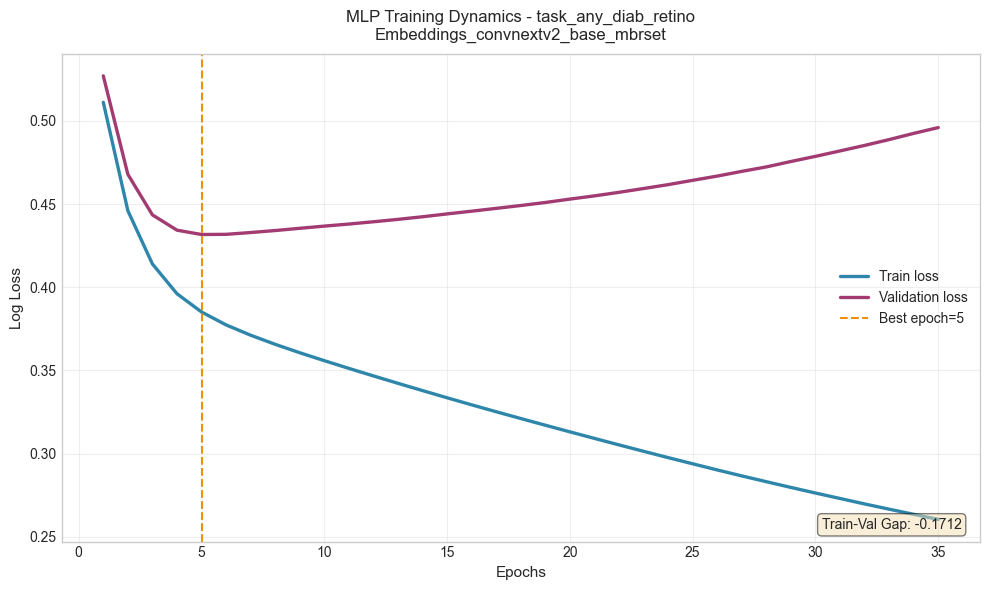


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 10, Stopped at: 35
  Final train loss: 0.1893, val loss: 0.3216


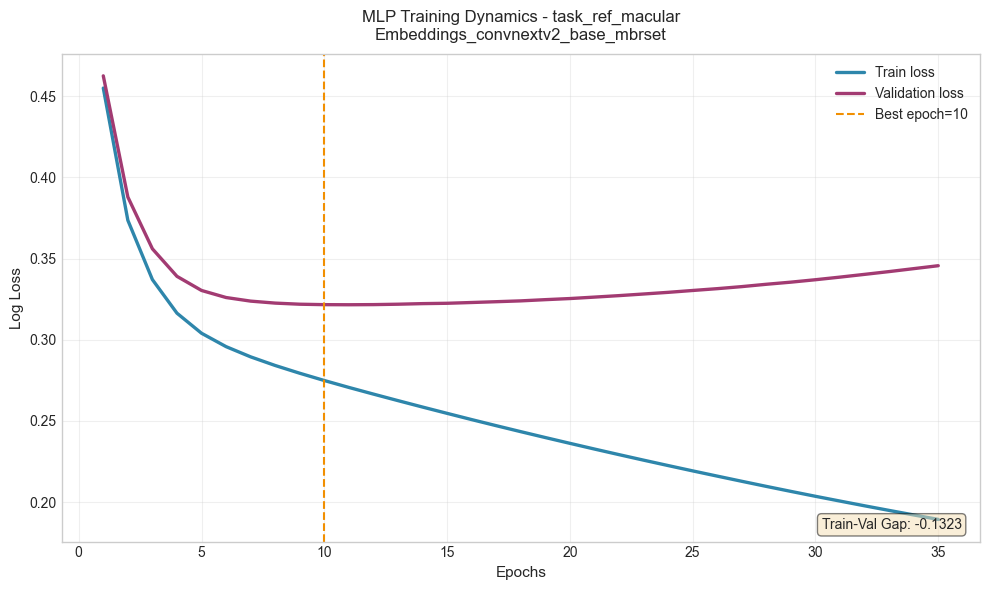


Embedding 2/7: Embeddings_mbrset_dinov3_convnext_base

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 12, Stopped at: 35
  Final train loss: 0.3216, val loss: 0.4447


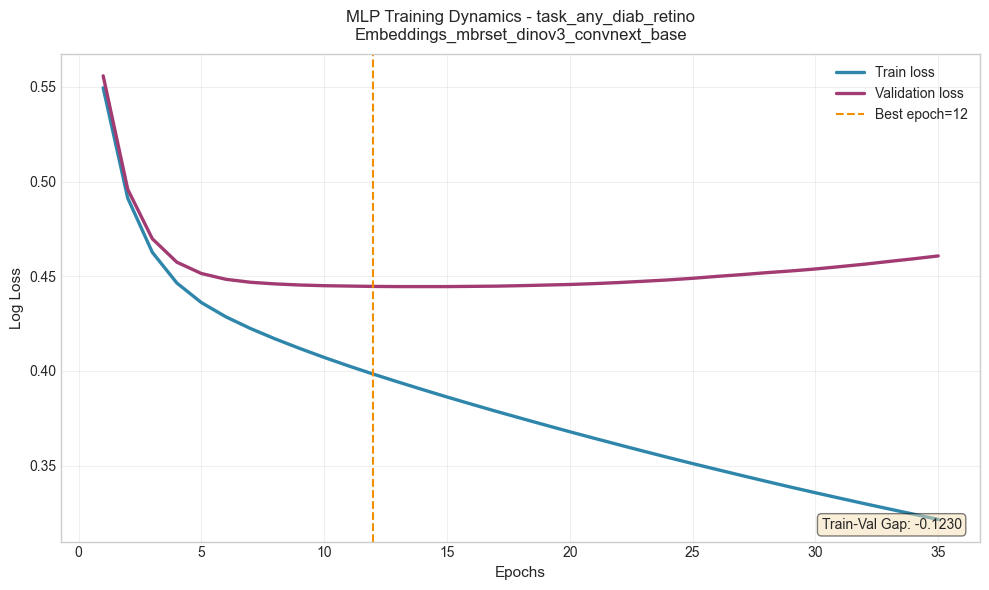


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 10, Stopped at: 35
  Final train loss: 0.2257, val loss: 0.3726


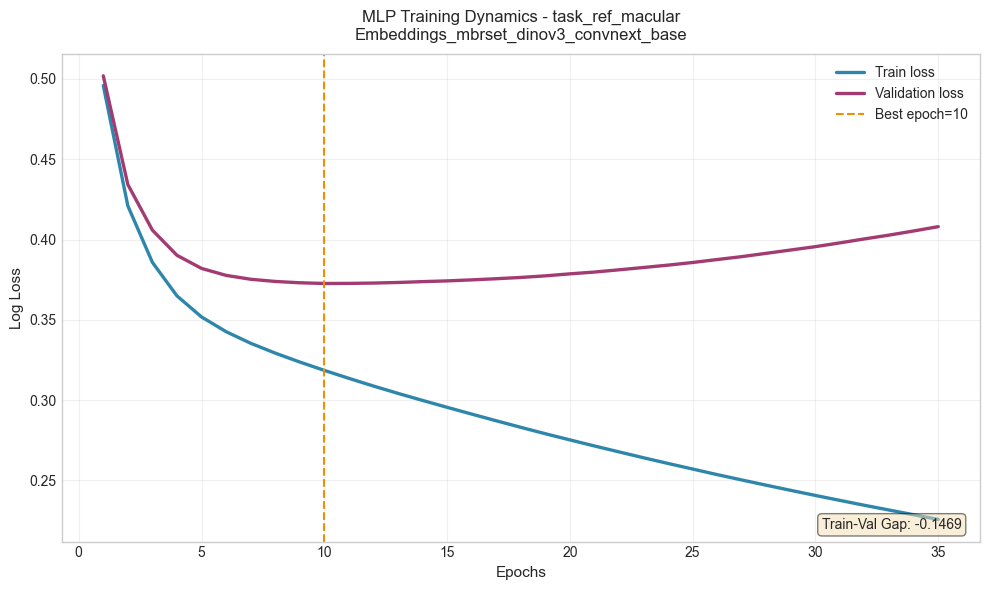


Embedding 3/7: Embeddings_mbrset_dinov3_vitb16

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 12, Stopped at: 35
  Final train loss: 0.2713, val loss: 0.4127


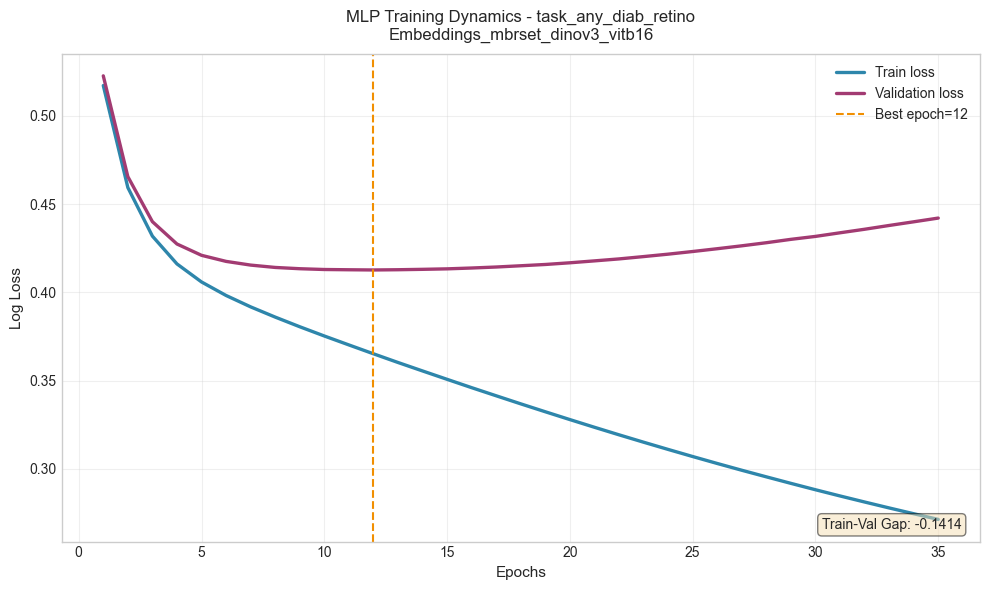


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 9, Stopped at: 35
  Final train loss: 0.1947, val loss: 0.3357


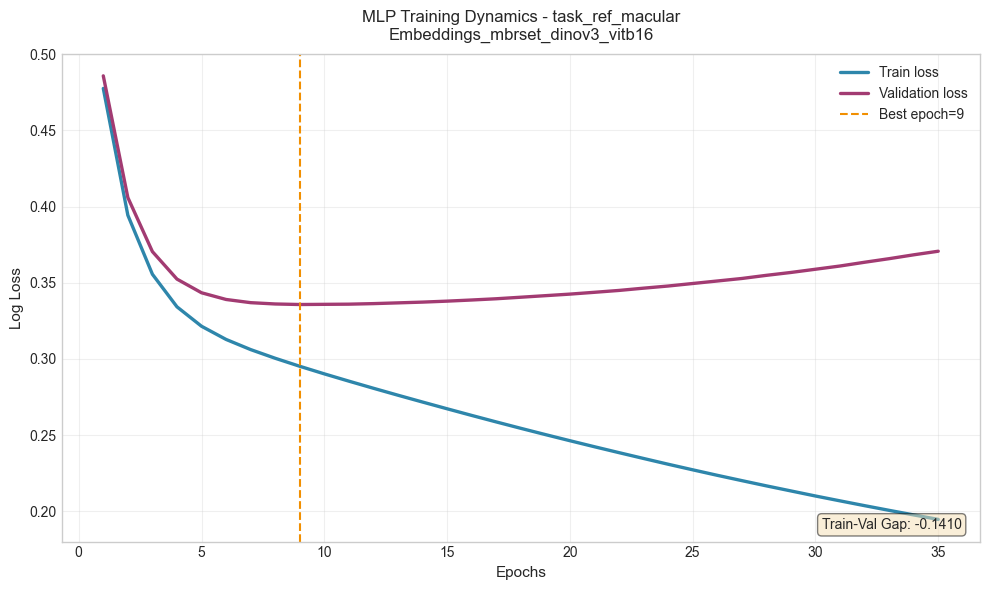


Embedding 4/7: Embeddings_mbrset_RETFound_dinov2_shanghai

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 5, Stopped at: 35
  Final train loss: 0.2785, val loss: 0.4279


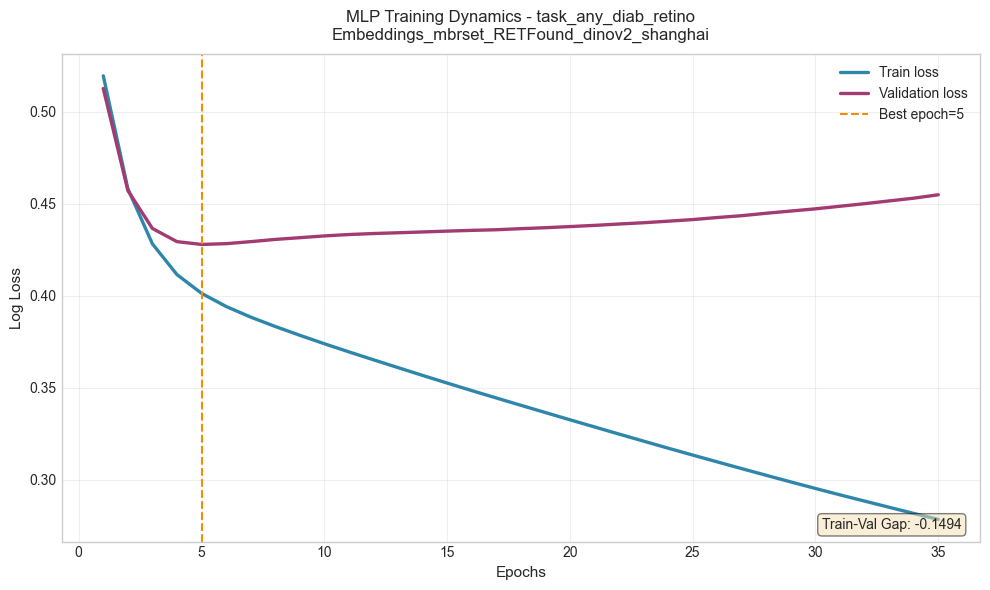


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 9, Stopped at: 35
  Final train loss: 0.1927, val loss: 0.3199


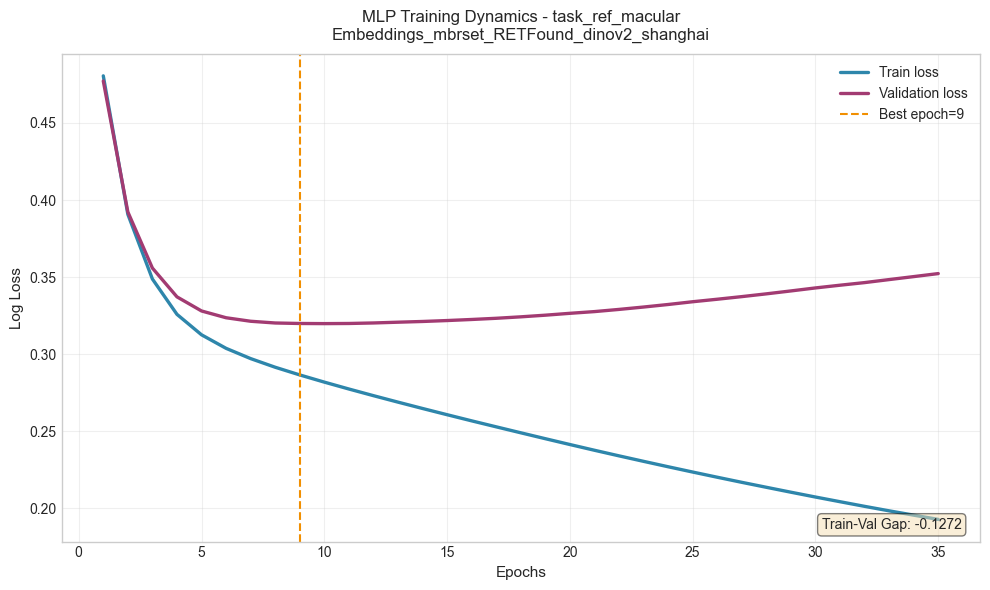


Embedding 5/7: Embeddings_mbrset_RETFound_mae_natureCFP

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 17, Stopped at: 37
  Final train loss: 0.3235, val loss: 0.4779


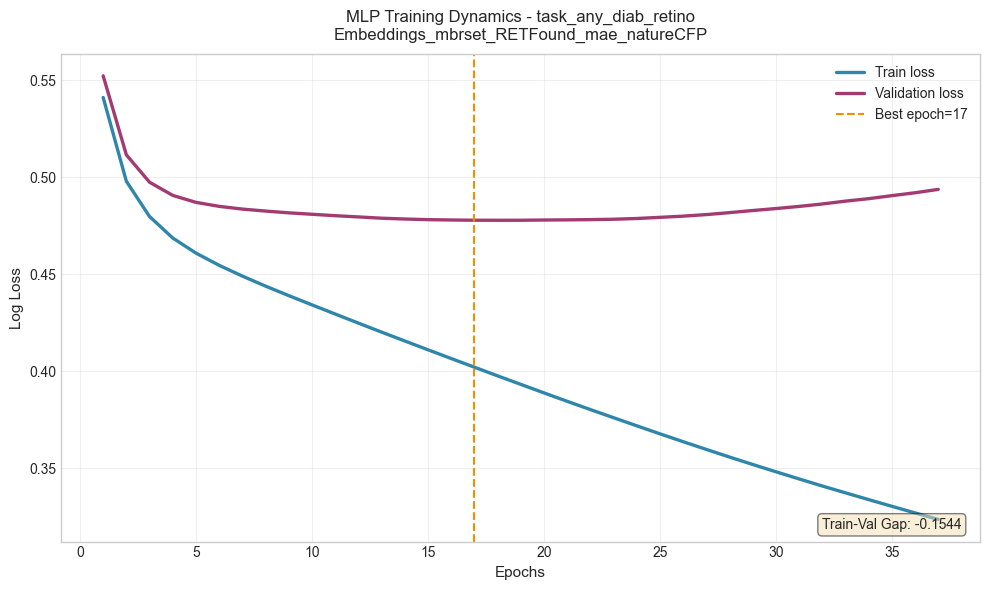


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 19, Stopped at: 39
  Final train loss: 0.2441, val loss: 0.3870


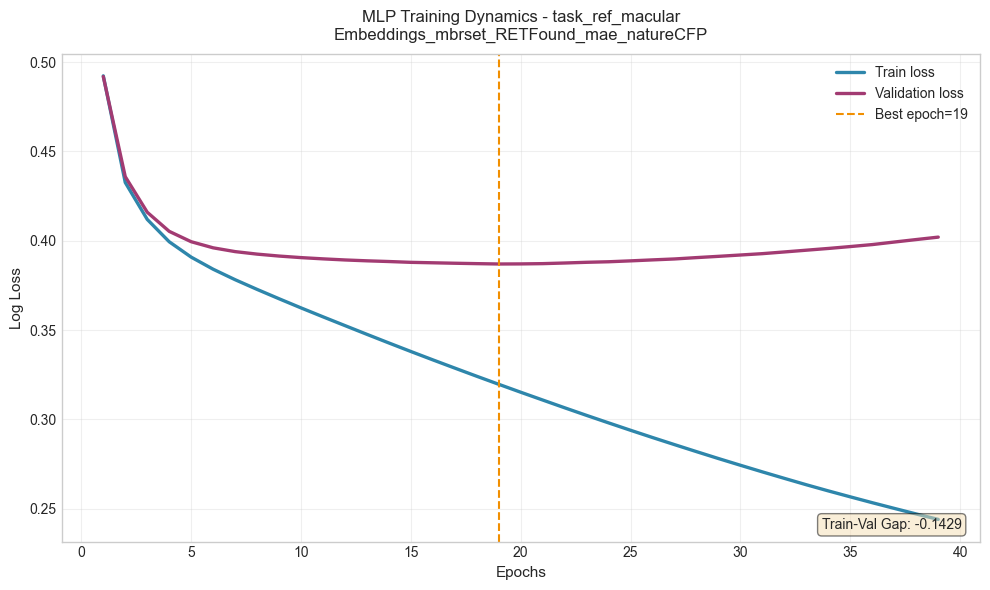


Embedding 6/7: Embeddings_mbrset_RETFound_mae_shanghai

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 15, Stopped at: 35
  Final train loss: 0.3564, val loss: 0.4852


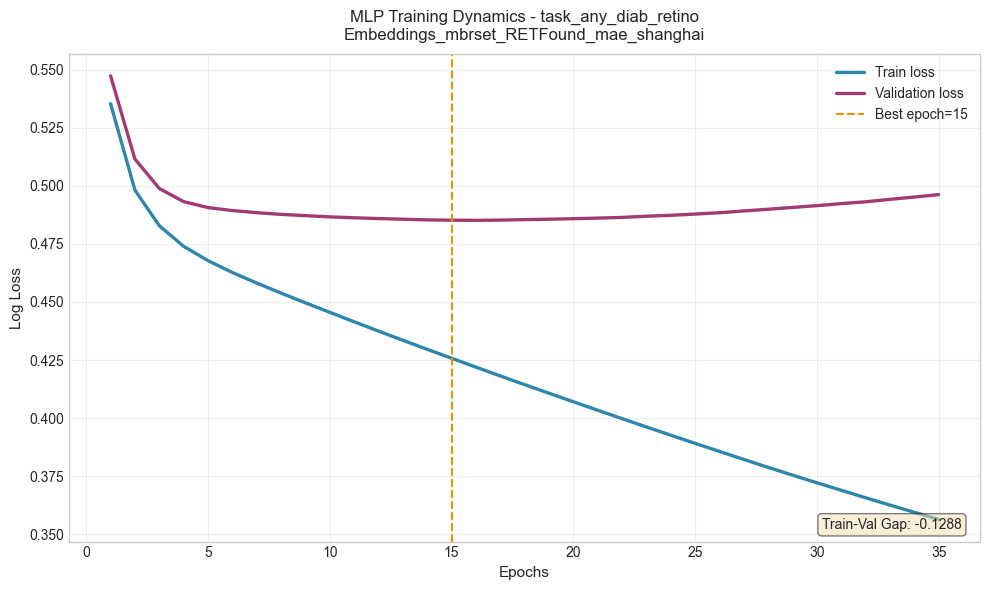


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 8, Stopped at: 35
  Final train loss: 0.2623, val loss: 0.4184


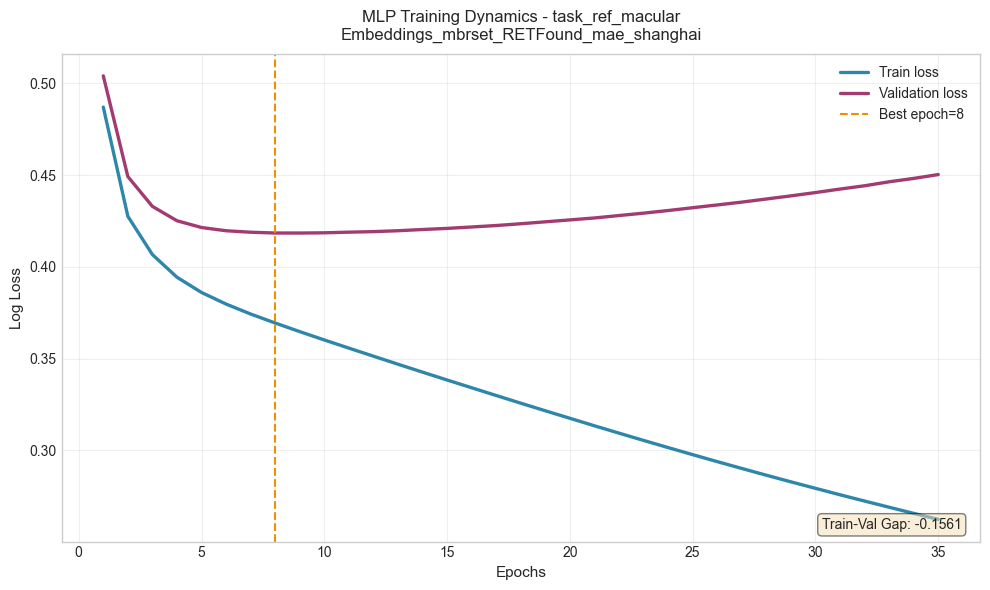


Embedding 7/7: Embeddings_vit_base_mbrset

--- Task: task_any_diab_retino (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 5, Stopped at: 35
  Final train loss: 0.3167, val loss: 0.4579


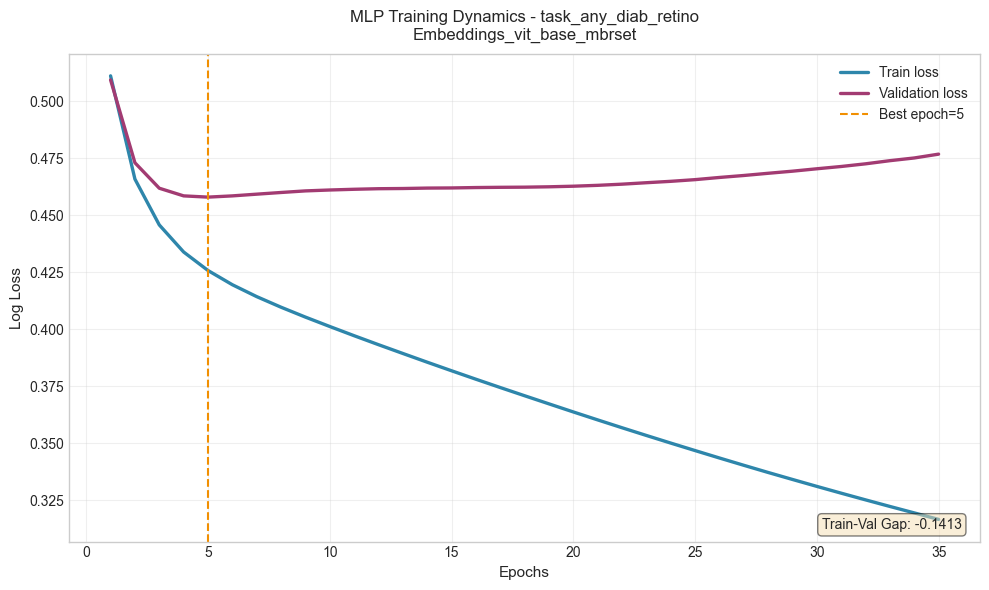


--- Task: task_ref_macular (binary) ---
  Train: 1754 images
  Internal Val: 310 images
  Applying PCA (n_components=30)...

  Training MLP with dynamics tracking...
  Config: hidden=(256,), alpha=1e-06, lr=0.0005, warmup=15
  Batch size: 64, Patience: 20
  Training without sample weights
  Best epoch: 6, Stopped at: 35
  Final train loss: 0.2366, val loss: 0.3914


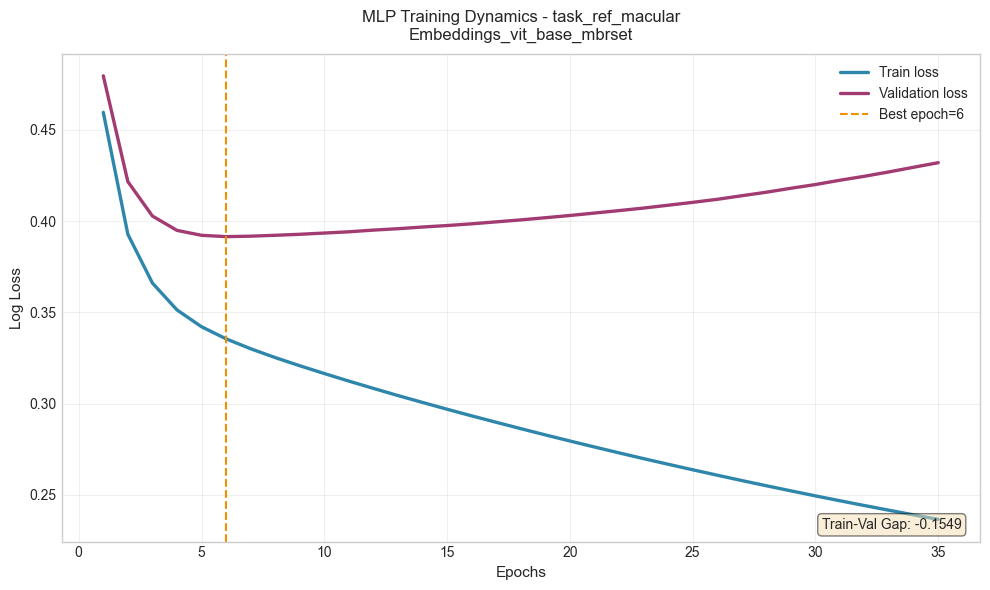


Training dynamics complete!


In [7]:
# Training dynamics: track train vs validation loss
# Set to 1 or 2 for faster analysis (or None to run all embeddings)
MAX_EMBEDDINGS_FOR_DYNAMICS = 7
DYNAMICS_DIR = RESULTS_DIR / "training_dynamics"
DYNAMICS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Running training dynamics analysis...")
print(f"Max embeddings: {MAX_EMBEDDINGS_FOR_DYNAMICS if MAX_EMBEDDINGS_FOR_DYNAMICS else 'all'}")

dynamics_embeddings = embedding_files[:MAX_EMBEDDINGS_FOR_DYNAMICS] if MAX_EMBEDDINGS_FOR_DYNAMICS else embedding_files

for emb_idx, emb_path in enumerate(dynamics_embeddings):
    print(f"\n{'='*70}")
    print(f"Embedding {emb_idx+1}/{len(dynamics_embeddings)}: {emb_path.stem}")
    print(f"{'='*70}")
    
    # Load dataset
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )
    
    # Apply split
    train_df, test_df = reval.apply_patient_split(ds.df, split, group_col="patient_id")
    
    # Loop over BINARY tasks only
    for task in BINARY_TASKS:
        if task not in ds.df.columns:
            continue
        
        display_task = BINARY_TASK_MAP.get(task, task)
        
        print(f"\n--- Task: {display_task} (binary) ---")
        
        # Prepare data
        train_work = train_df.dropna(subset=[task]).copy()
        
        if train_work.empty:
            print(f"  Skipping {task}: insufficient data")
            continue
        
        X_train_full = train_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_train_full = train_work[task].astype(int).to_numpy()
        
        # Create internal validation split (15% of training data for more stable early stopping)
        from sklearn.model_selection import train_test_split
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train_full
        )
        
        print(f"  Train: {len(X_train)} images")
        print(f"  Internal Val: {len(X_val)} images")
        
        # Apply PCA for dynamics analysis (to match main training)
        if USE_PCA:
            print(f"  Applying PCA (n_components={PCA_N_COMPONENTS})...")
            pca_dyn = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
            X_train = pca_dyn.fit_transform(X_train)
            X_val = pca_dyn.transform(X_val)
        
        # Resolve per-embedding configs
        mlp_cfg, mlp_match = resolve_config(emb_path.stem)
        if mlp_match:
            print(f"  Per-embedding overrides applied (matched: {mlp_match})")
        
        # --- MLP Training Dynamics ---
        print(f"\n  Training MLP with dynamics tracking...")
        warmup = mlp_cfg.get("warmup_epochs", 0)
        print(f"  Config: hidden={mlp_cfg['hidden_layer_sizes']}, alpha={mlp_cfg['alpha']}, lr={mlp_cfg['learning_rate_init']}, warmup={warmup}")
        print(f"  Batch size: {mlp_cfg['batch_size']}, Patience: {mlp_cfg['patience']}")
        
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_val_s = scaler.transform(X_val)
        
        # Compute balanced sample weights for class-aware validation
        if RUN_WEIGHTED_VERSION:
            train_weights = compute_balanced_weights(y_train)
            val_weights = compute_balanced_weights(y_val)
            print(f"  Training with weighted validation (train_weights mean={train_weights.mean():.3f})")
        else:
            train_weights = None
            val_weights = None
            print(f"  Training without sample weights")
        
        mlp = MLPClassifier(
            hidden_layer_sizes=mlp_cfg["hidden_layer_sizes"],
            alpha=mlp_cfg["alpha"],
            learning_rate_init=mlp_cfg["learning_rate_init"],
            batch_size=mlp_cfg["batch_size"],
            max_iter=1,
            warm_start=True,
            early_stopping=False,
            random_state=RANDOM_SEED,
        )
        
        mlp_train_loss = []
        mlp_val_loss = []
        best_val_loss = float("inf")
        best_epoch = 0
        best_model = None
        patience_counter = 0
        
        labels = np.unique(np.concatenate([y_train, y_val]))
        
        for epoch in range(1, mlp_cfg["max_epochs"] + 1):
            if train_weights is not None:
                mlp.fit(X_train_s, y_train)  # Note: sklearn MLP doesn't support sample_weight directly
            else:
                mlp.fit(X_train_s, y_train)
            
            # Compute weighted losses for fair class-aware comparison
            train_proba = mlp.predict_proba(X_train_s)
            val_proba = mlp.predict_proba(X_val_s)
            
            tr_loss = float(weighted_log_loss(y_train, train_proba, labels=labels, sample_weight=train_weights))
            va_loss = float(weighted_log_loss(y_val, val_proba, labels=labels, sample_weight=val_weights))
            
            mlp_train_loss.append(tr_loss)
            mlp_val_loss.append(va_loss)
            
            # Early stopping with warmup — skip patience counting for first N epochs
            if va_loss < best_val_loss - mlp_cfg["min_delta"]:
                best_val_loss = va_loss
                best_epoch = epoch
                best_model = copy.deepcopy(mlp)
                patience_counter = 0
            elif epoch > warmup:
                patience_counter += 1
                if patience_counter >= mlp_cfg["patience"]:
                    break
        
        mlp_stop_epoch = len(mlp_val_loss)
        
        print(f"  Best epoch: {best_epoch}, Stopped at: {mlp_stop_epoch}")
        print(f"  Final train loss: {mlp_train_loss[-1]:.4f}, val loss: {mlp_val_loss[best_epoch-1]:.4f}")
        
        # --- Plot Training Dynamics ---
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # MLP plot
        epochs = np.arange(1, len(mlp_train_loss) + 1)
        ax.plot(epochs, mlp_train_loss, label="Train loss", linewidth=2.4, color="#2E86AB")
        ax.plot(epochs, mlp_val_loss, label="Validation loss", linewidth=2.4, color="#A23B72")
        ax.axvline(best_epoch, linestyle="--", linewidth=1.5, color="#F18F01",
                   label=f"Best epoch={best_epoch}")
        ax.set_xlabel("Epochs", fontsize=11)
        ax.set_ylabel("Log Loss", fontsize=11)
        ax.set_title(f"MLP Training Dynamics - {display_task}\n{emb_path.stem}", fontsize=12, pad=10)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Add gap annotation
        final_gap_mlp = mlp_train_loss[-1] - mlp_val_loss[best_epoch-1]
        ax.text(0.98, 0.02, f"Train-Val Gap: {final_gap_mlp:.4f}", 
                transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
                horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        
        # Save plot
        out_name = f"dynamics_{emb_idx:02d}_{emb_path.stem}_{display_task}.png"
        fig.savefig(DYNAMICS_DIR / out_name, dpi=160, bbox_inches="tight")
        
        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(fig)
        
        # Save loss curves as CSV
        mlp_df = pd.DataFrame({
            "epoch": epochs,
            "train_loss": mlp_train_loss,
            "val_loss": mlp_val_loss,
        })
        mlp_df.to_csv(DYNAMICS_DIR / f"mlp_{emb_idx:02d}_{emb_path.stem}_{display_task}.csv", index=False)


print(f"\n{'='*70}")
print(f"Training dynamics complete!")

## Summary

This notebook performed patient-level evaluation on MBRSET using:
- **Single 80/20 patient split** (reused for all embeddings)
- **MLP with Bayesian hyperparameter search (BayesSearchCV)**
- **Hyperparameter search space**: 1-5 layers, up to 1024 neurons per layer
- **Batch size**: 64, **Patience**: 10
- **NO sample weights** (unweighted training for comparison)
- **Patient-level aggregation** (majority vote for predictions, average for probabilities)
- **Comprehensive outputs** (reports, confusion matrices, ROC curves, best hyperparameters)

All results are saved in the `results/mbrset_patient_eval_unweighted/` directory.